Importem llibreries y gràfica

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuració estètica
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

Importem DF

##### ESTA ANALISIS LO HICE QUITANDO LOS VALORES 0 DE MOUNTH ABS. Y TAMBIEN HICE POR FRECUENCIA Y HORAS, PARA MI, FRECUENCIA NO TIENE MUCHO SENTIDO ENTONCES NOS QUEDAMOS CON HORAS.

In [38]:
# Instalar pyarrow si no lo tienes
# !pip install pyarrow

import pandas as pd

# Leer el archivo Parquet correctamente
RRHH = pd.read_parquet(r"C:\Users\Lucan Vieira\ProjecteData\Equip_15\Data\RRHH_220925_clean.parquet")

# Mostrar las primeras filas para verificar
print(RRHH.head())

   ID Reason_absence Month_absence   Day_week    Seasons  \
0  14             11     Noviembre      Lunes  Primavera   
1  36             13         Abril  Miercoles     Verano   
2   9              6         Julio     Martes   Invierno   
3  28              9         Julio     Martes   Invierno   
4   9             12         Marzo     Martes      Otono   

   Transportation_expense  Distance_Residence_Work  Service_time   Age  \
0                   155.0                     12.0          14.0  34.0   
1                   118.0                     13.0          18.0  50.0   
2                   228.0                     14.0          16.0  58.0   
3                   225.0                     26.0           9.0  28.0   
4                   228.0                     14.0          16.0  58.0   

   Work_load_Average_day  ...  Social_smoker  Pet Weight  Height  \
0                284.031  ...              0    0   95.0   196.0   
1                239.409  ...              0    0   98.0  

In [66]:
print("Tipos de datos por columna:")
print(RRHH.dtypes)

# Información detallada
print("\nInformación completa del dataset:")
print(RRHH.info())

# Estadísticas descriptivas por tipo de dato
print("\nResumen de datos numéricos:")
print(RRHH.describe())


Tipos de datos por columna:
ID                                  int64
Reason_absence             string[python]
Month_absence              string[python]
Day_week                   string[python]
Seasons                    string[python]
Transportation_expense            float64
Distance_Residence_Work           float64
Service_time                      float64
Age                               float64
Work_load_Average_day             float64
Hit_target                        float64
Disciplinary_failure                int64
Education                  string[python]
Son                                 int64
Social_drinker                      int64
Social_smoker                       int64
Pet                                 int64
Weight                            float64
Height                            float64
Body_mass_index                   float64
Absenteeism_hours                 float64
Education_numeric                   int64
Month_absence_order                 int64
Day_we

In [61]:
df= RRHH
print (df)

      ID Reason_absence Month_absence   Day_week    Seasons  \
0     14             11     Noviembre      Lunes  Primavera   
1     36             13         Abril  Miercoles     Verano   
2      9              6         Julio     Martes   Invierno   
3     28              9         Julio     Martes   Invierno   
4      9             12         Marzo     Martes      Otono   
..   ...            ...           ...        ...        ...   
801  132             19       Febrero     Jueves      Otono   
802  133             23        Agosto    Viernes   Invierno   
803  134             23         Julio    Viernes   Invierno   
804  135             23         Marzo      Lunes      Otono   
805  136             23          Mayo  Miercoles     Verano   

     Transportation_expense  Distance_Residence_Work  Service_time   Age  \
0                     155.0                     12.0          14.0  34.0   
1                     118.0                     13.0          18.0  50.0   
2              

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')

# Cargar datos (asumiendo que ya tienes el DataFrame)
# df = pd.read_csv('tu_archivo.csv')

# Eliminar registros con Month_absence = '0'
print(f"Registros antes de limpiar: {len(df)}")
df_clean = df[df['Month_absence'] != '0'].copy()
print(f"Registros después de limpiar: {len(df_clean)}")
print(f"Registros eliminados: {len(df) - len(df_clean)}")

Registros antes de limpiar: 806
Registros después de limpiar: 801
Registros eliminados: 5


In [63]:
# Configuración de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Variables personales vs laborales
variables_personales = ['Son', 'Social_drinker', 'Education_numeric', 'Age', 
                       'Social_smoker', 'Pet', 'Weight', 'Height', 'Body_mass_index']

variables_laborales = ['Month_absence_order', 'Day_week_order', 'Seasons_order', 
                      'Transportation_expense', 'Distance_Residence_Work', 
                      'Service_time', 'Work_load_Average_day', 'Hit_target', 
                      'Disciplinary_failure']

target_variable = 'Absenteeism_hours'

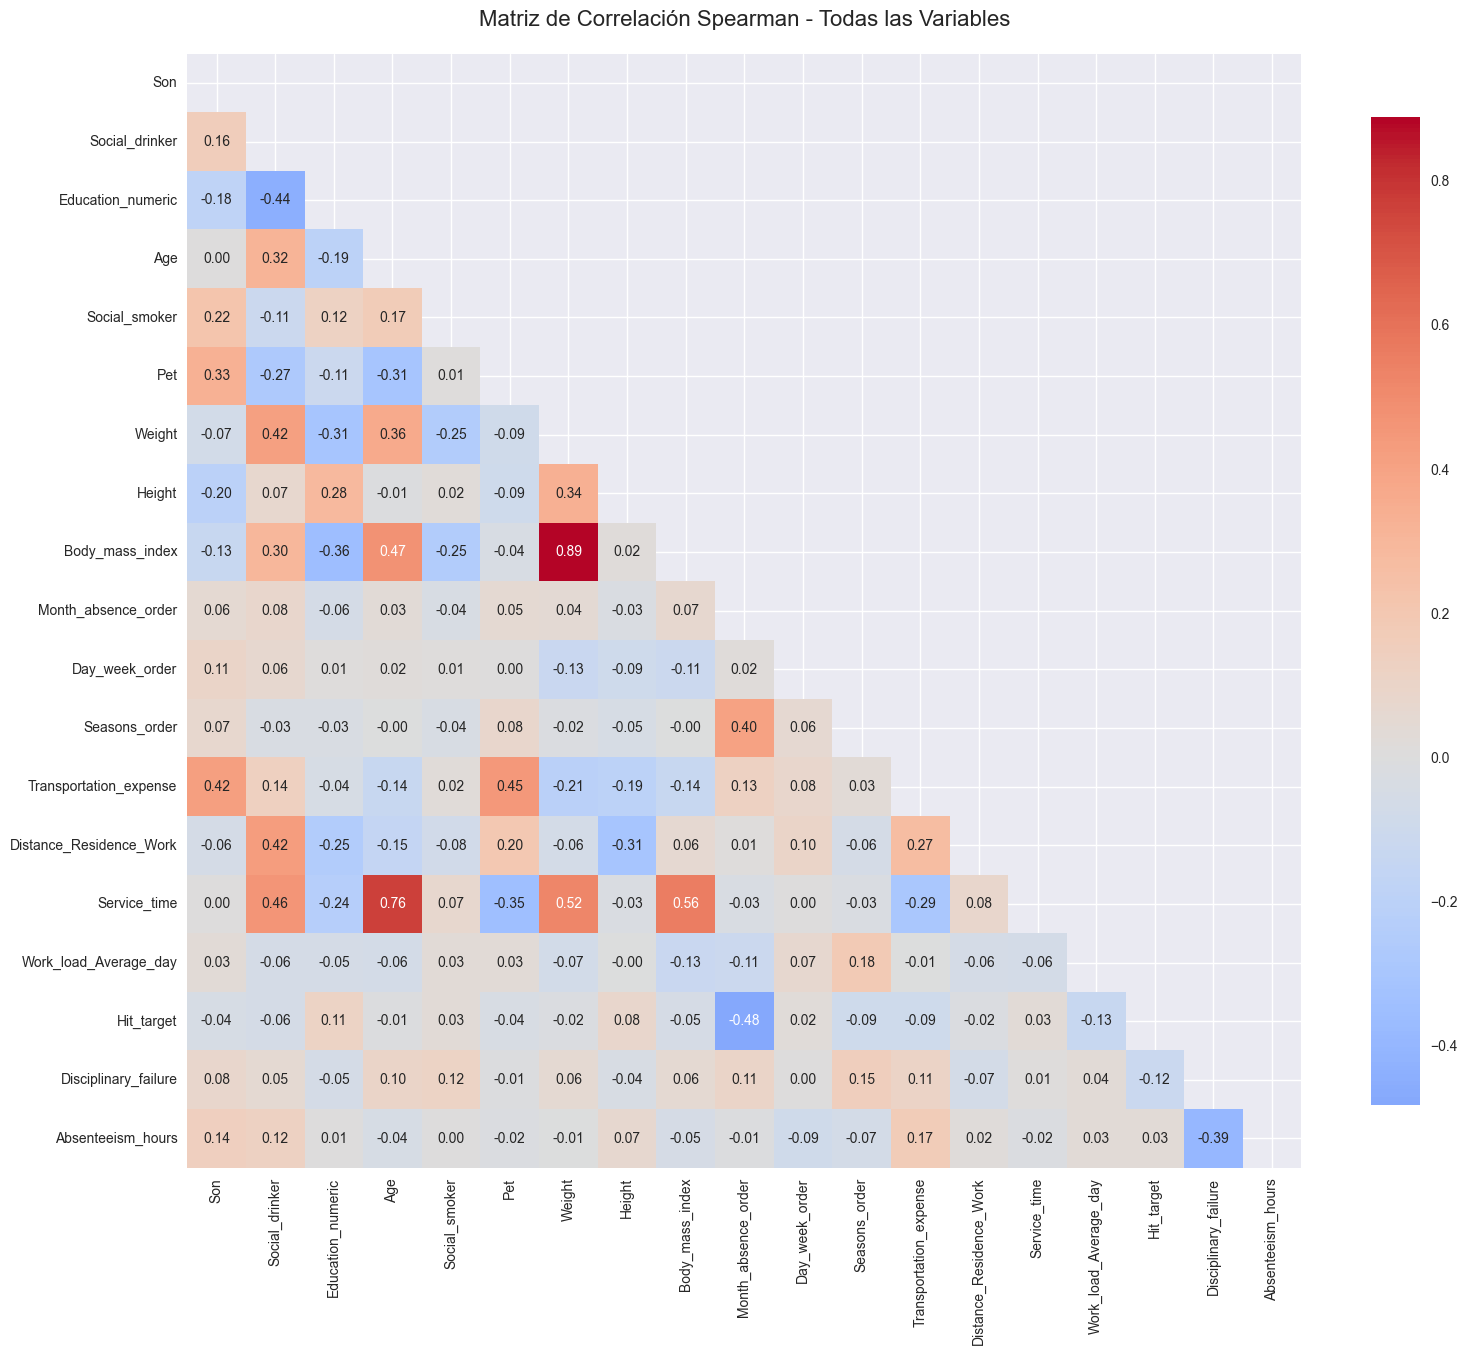

In [67]:
# Combinar todas las variables relevantes
todas_variables = variables_personales + variables_laborales + [target_variable]

# Matriz de correlación Spearman
corr_spearman = df_clean[todas_variables].corr(method='spearman')

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(corr_spearman, mask=mask, annot=True, cmap='coolwarm', center=0,
           square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación Spearman - Todas las Variables', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

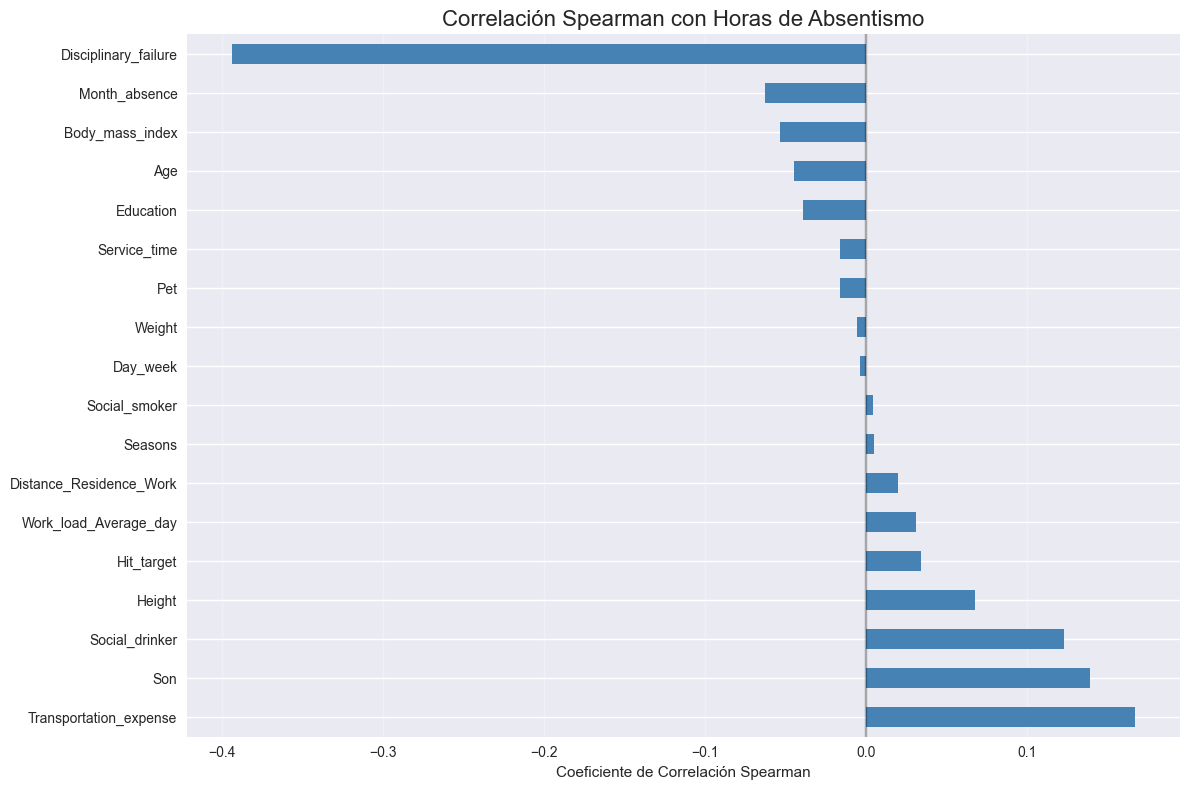

Top 5 variables con mayor correlación Spearman:
Transportation_expense     0.167054
Son                        0.139111
Social_drinker             0.123040
Height                     0.067824
Hit_target                 0.034293
Work_load_Average_day      0.030838
Distance_Residence_Work    0.019869
Seasons                    0.004724
Social_smoker              0.004704
Day_week                  -0.003844
dtype: float64


In [64]:
# Correlaciones con la variable objetivo
correlaciones_objetivo = df_clean[todas_variables].corrwith(df_clean['Absenteeism_hours'], method='spearman')
correlaciones_objetivo = correlaciones_objetivo.drop('Absenteeism_hours').sort_values(ascending=False)

plt.figure(figsize=(12, 8))
correlaciones_objetivo.plot(kind='barh', color='steelblue')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.title('Correlación Spearman con Horas de Absentismo', fontsize=16)
plt.xlabel('Coeficiente de Correlación Spearman')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 variables con mayor correlación Spearman:")
print(correlaciones_objetivo.head(10))

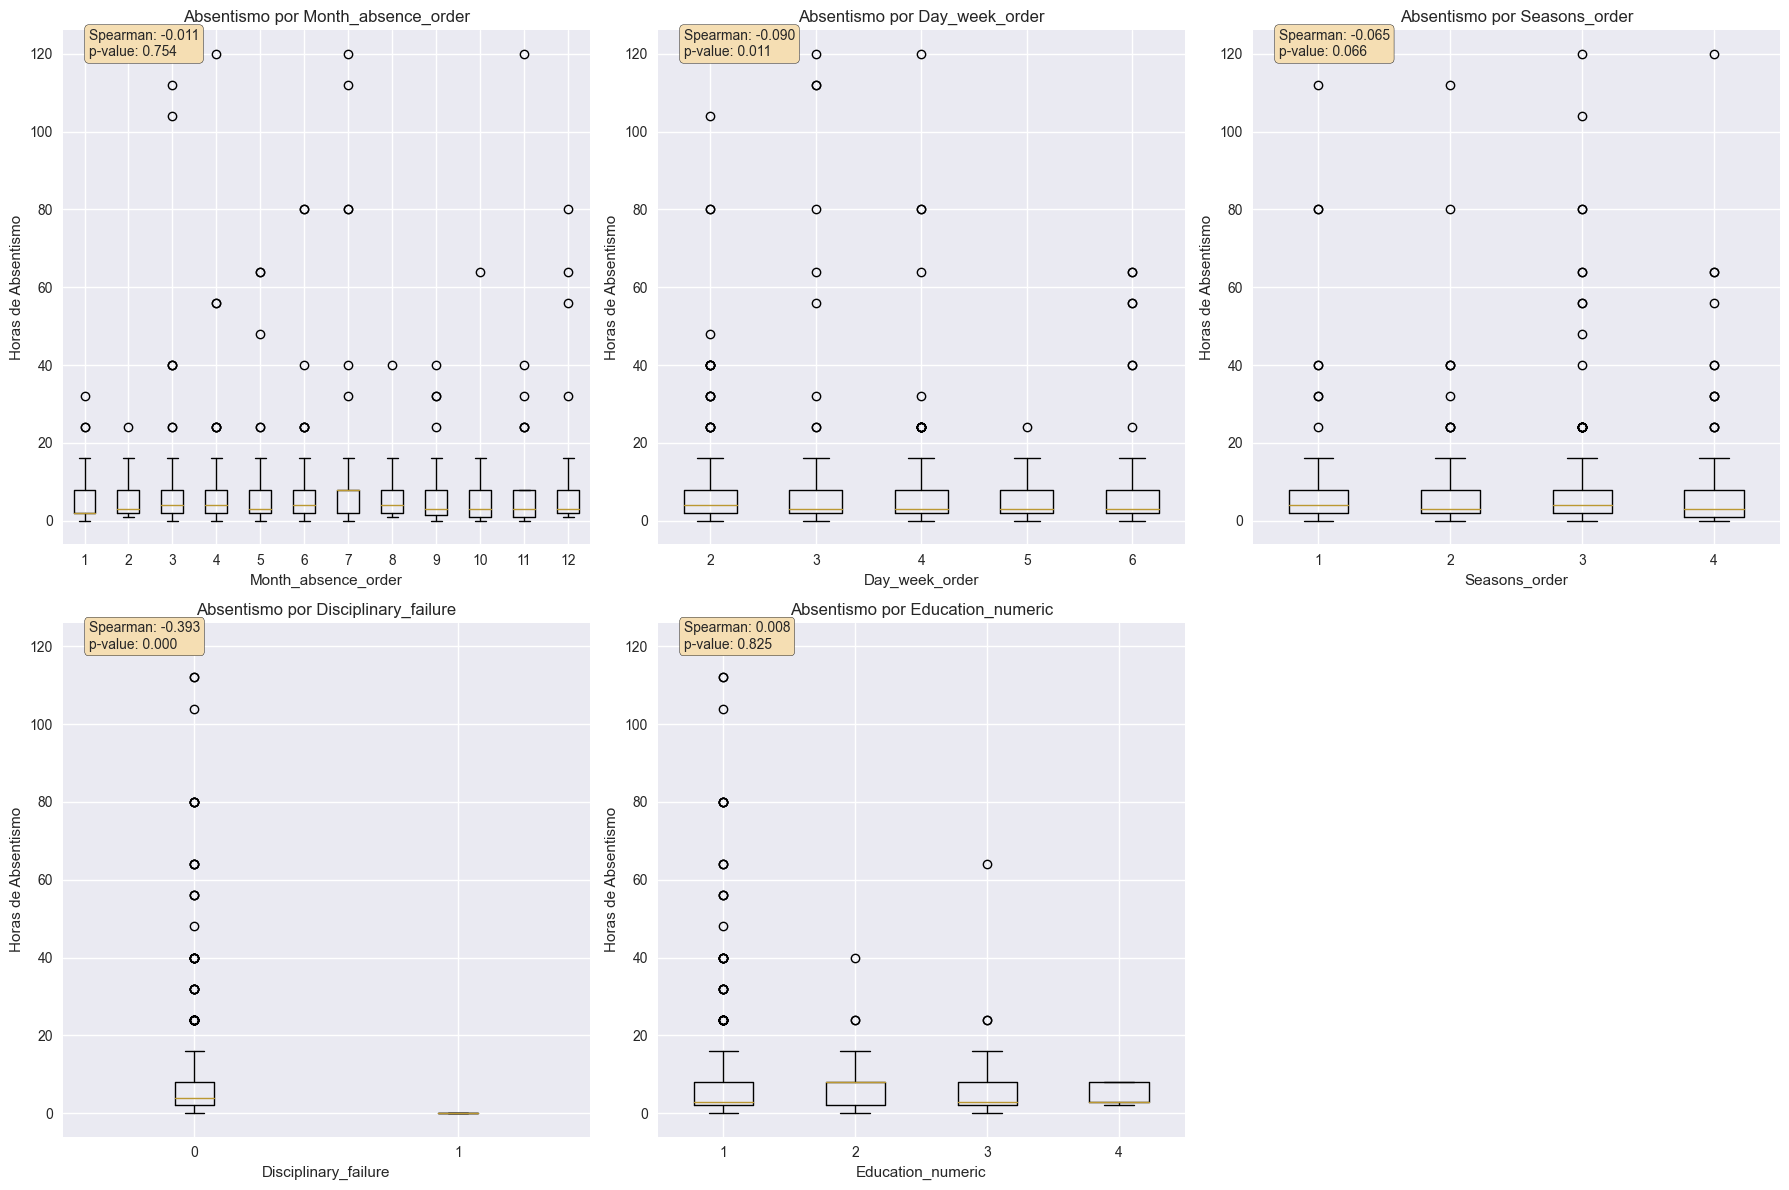

In [68]:
# Boxplots para variables categóricas ordenadas
categorical_vars = ['Month_absence_order', 'Day_week_order', 'Seasons_order', 
                   'Disciplinary_failure', 'Education_numeric']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, var in enumerate(categorical_vars):
    # Agrupar por categorías y crear boxplot
    data_to_plot = []
    categories = sorted(df_clean[var].unique())
    
    for category in categories:
        data_to_plot.append(df_clean[df_clean[var] == category]['Absenteeism_hours'])
    
    axes[i].boxplot(data_to_plot, labels=categories)
    axes[i].set_title(f'Absentismo por {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Horas de Absentismo')
    
    # Calcular correlación Spearman
    corr, p_value = spearmanr(df_clean[var], df_clean['Absenteeism_hours'])
    axes[i].text(0.05, 0.95, f'Spearman: {corr:.3f}\np-value: {p_value:.3f}', 
                transform=axes[i].transAxes, bbox=dict(boxstyle="round", facecolor='wheat'))

# Ocultar el último subplot si no se usa
if len(categorical_vars) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

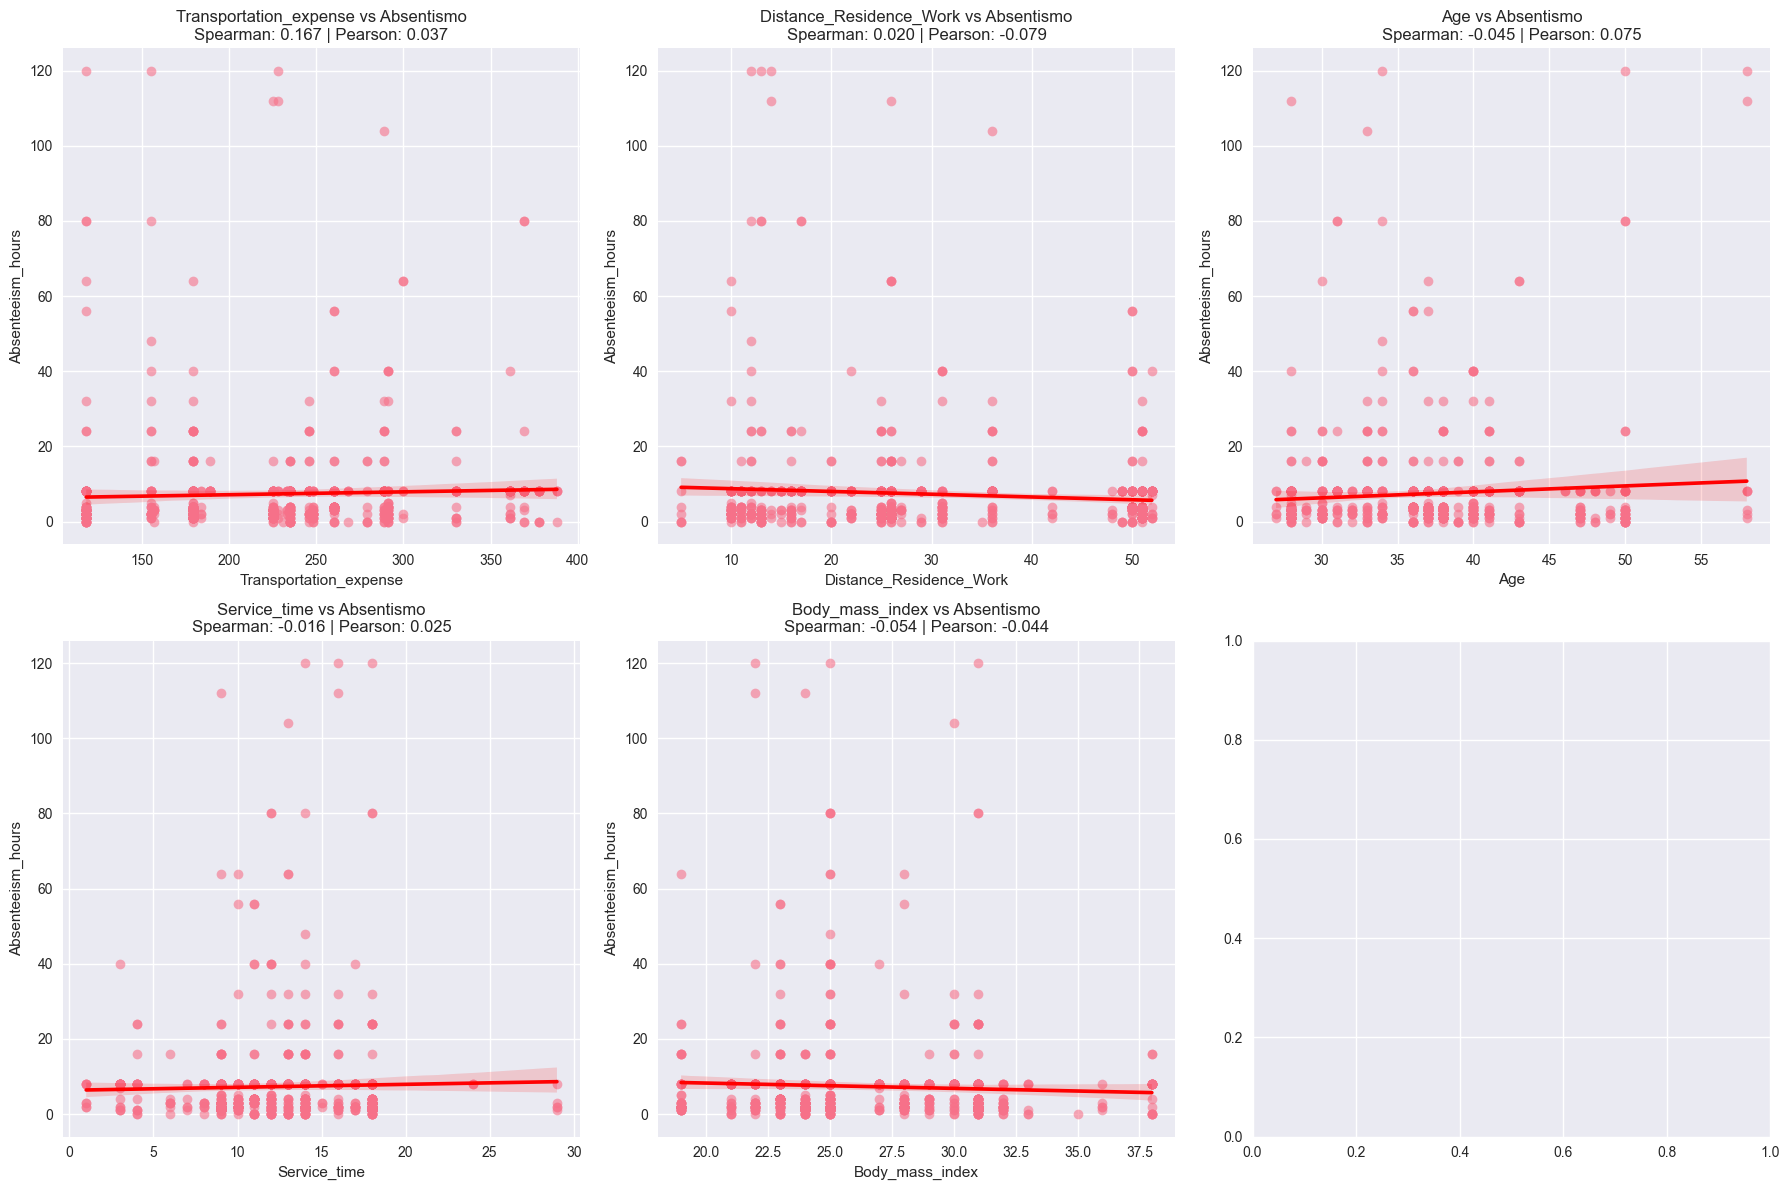

In [69]:
# Variables continuas más prometedoras
continuous_vars = ['Transportation_expense', 'Distance_Residence_Work', 'Age', 
                  'Service_time', 'Body_mass_index']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, var in enumerate(continuous_vars):
    if i < len(continuous_vars):
        # Scatter plot con línea de tendencia
        sns.regplot(data=df_clean, x=var, y='Absenteeism_hours', 
                   ax=axes[i], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
        
        # Calcular ambas correlaciones
        spear_corr, spear_p = spearmanr(df_clean[var], df_clean['Absenteeism_hours'])
        pearson_corr, pearson_p = pearsonr(df_clean[var], df_clean['Absenteeism_hours'])
        
        axes[i].set_title(f'{var} vs Absentismo\nSpearman: {spear_corr:.3f} | Pearson: {pearson_corr:.3f}')
        axes[i].set_xlabel(var)

# Ajustar layout
plt.tight_layout()
plt.show()

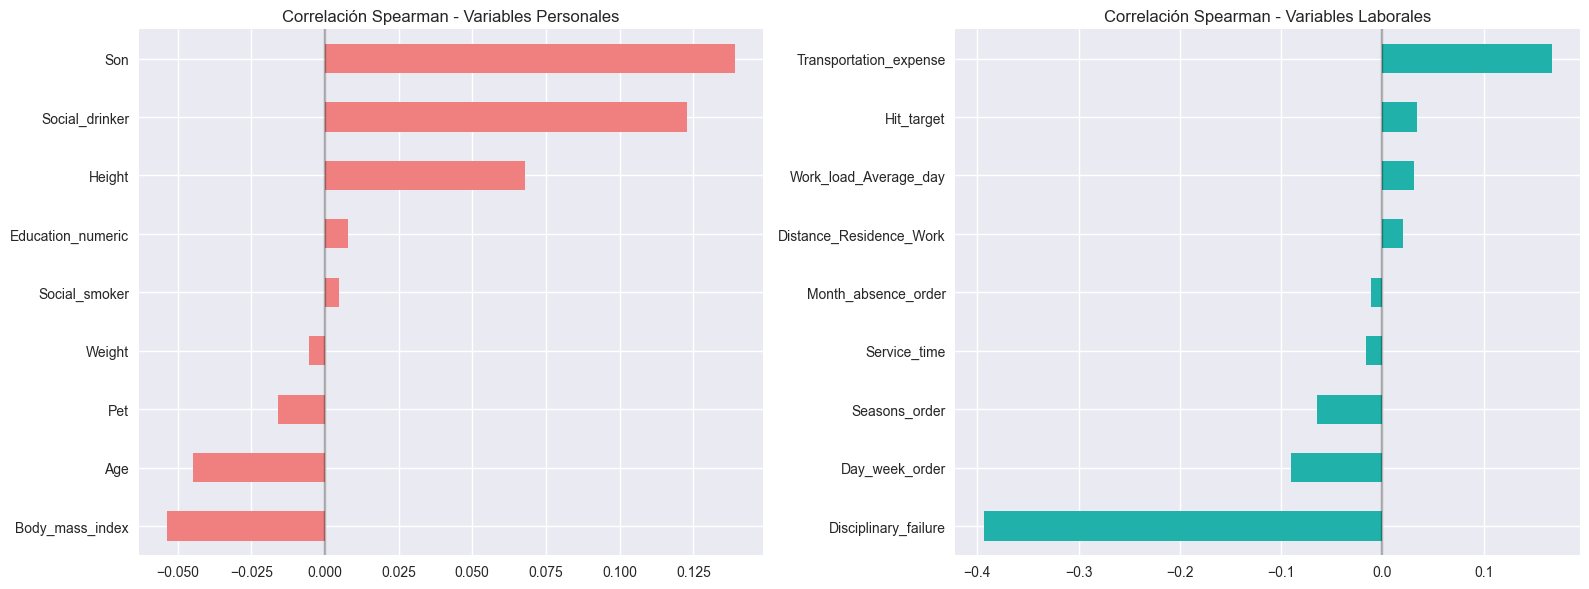

Resumen de correlaciones promedio:
Variables personales: 0.051
Variables laborales: 0.092


In [70]:
# Comparar correlaciones entre grupos
corr_personal = df_clean[variables_personales + ['Absenteeism_hours']].corrwith(
    df_clean['Absenteeism_hours'], method='spearman').drop('Absenteeism_hours')

corr_laboral = df_clean[variables_laborales + ['Absenteeism_hours']].corrwith(
    df_clean['Absenteeism_hours'], method='spearman').drop('Absenteeism_hours')

# Gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Variables personales
corr_personal.sort_values().plot(kind='barh', ax=ax1, color='lightcoral')
ax1.set_title('Correlación Spearman - Variables Personales')
ax1.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# Variables laborales
corr_laboral.sort_values().plot(kind='barh', ax=ax2, color='lightseagreen')
ax2.set_title('Correlación Spearman - Variables Laborales')
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

print("Resumen de correlaciones promedio:")
print(f"Variables personales: {corr_personal.abs().mean():.3f}")
print(f"Variables laborales: {corr_laboral.abs().mean():.3f}")

In [71]:
# Tabla resumen de correlaciones
resumen_correlaciones = []

for variable in todas_variables:
    if variable != 'Absenteeism_hours':
        spear_corr, spear_p = spearmanr(df_clean[variable], df_clean['Absenteeism_hours'])
        pearson_corr, pearson_p = pearsonr(df_clean[variable], df_clean['Absenteeism_hours'])
        
        resumen_correlaciones.append({
            'Variable': variable,
            'Tipo': 'Personal' if variable in variables_personales else 'Laboral',
            'Spearman_Corr': spear_corr,
            'Spearman_p_value': spear_p,
            'Pearson_Corr': pearson_corr,
            'Pearson_p_value': pearson_p,
            'Significativo_Spearman': spear_p < 0.05,
            'Significativo_Pearson': pearson_p < 0.05
        })

df_resumen = pd.DataFrame(resumen_correlaciones)
df_resumen = df_resumen.sort_values('Spearman_Corr', key=abs, ascending=False)

print("Resumen Estadístico de Correlaciones:")
print("="*80)
print(df_resumen.to_string(index=False))

# Variables más significativas
print("\n" + "="*80)
print("VARIABLES MÁS RELEVANTES (p-value < 0.05):")
print("="*80)

significativas = df_resumen[df_resumen['Significativo_Spearman']].sort_values('Spearman_Corr', key=abs, ascending=False)
print(significativas[['Variable', 'Tipo', 'Spearman_Corr', 'Spearman_p_value']].to_string(index=False))

Resumen Estadístico de Correlaciones:
               Variable     Tipo  Spearman_Corr  Spearman_p_value  Pearson_Corr  Pearson_p_value  Significativo_Spearman  Significativo_Pearson
   Disciplinary_failure  Laboral      -0.393486      4.641590e-31     -0.125583         0.000367                    True                   True
 Transportation_expense  Laboral       0.167054      1.994198e-06      0.037224         0.292696                    True                  False
                    Son Personal       0.139111      7.809078e-05      0.122301         0.000522                    True                   True
         Social_drinker Personal       0.123040      4.828381e-04      0.085826         0.015110                    True                   True
         Day_week_order  Laboral      -0.090050      1.077912e-02     -0.102797         0.003585                    True                   True
                 Height Personal       0.067824      5.501584e-02      0.126537         0.000331  

In [72]:
# Identificar outliers en absenteeism hours
Q1 = df_clean['Absenteeism_hours'].quantile(0.25)
Q3 = df_clean['Absenteeism_hours'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df_clean[df_clean['Absenteeism_hours'] > limite_superior]
print(f"\nAnálisis de Outliers:")
print(f"Límite superior para outliers: {limite_superior:.2f} horas")
print(f"Número de outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)")
print(f"Horas máximas de absentismo: {df_clean['Absenteeism_hours'].max():.2f}")


Análisis de Outliers:
Límite superior para outliers: 17.00 horas
Número de outliers: 52 (6.5%)
Horas máximas de absentismo: 120.00


#### analisis por frecuencia 


In [73]:
# PRIMERO: Agrupar por empleado para calcular FRECUENCIA
frecuencia_ausencias = df_clean.groupby('ID').agg({
    'Absenteeism_hours': 'count',  # Esto será la FRECUENCIA
    'Son': 'first',
    'Social_drinker': 'first', 
    'Education_numeric': 'first',
    'Age': 'first',
    'Social_smoker': 'first',
    'Pet': 'first',
    'Weight': 'first',
    'Height': 'first',
    'Body_mass_index': 'first',
    'Transportation_expense': 'first',
    'Distance_Residence_Work': 'first',
    'Service_time': 'first',
    'Work_load_Average_day': 'first',
    'Hit_target': 'first',
    'Disciplinary_failure': 'first'
}).reset_index()

frecuencia_ausencias = frecuencia_ausencias.rename(columns={'Absenteeism_hours': 'Frecuencia_ausencias'})

print(f"Número de empleados únicos: {len(frecuencia_ausencias)}")
print(f"Frecuencia de ausencias por empleado:")
print(frecuencia_ausencias['Frecuencia_ausencias'].describe())

Número de empleados únicos: 132
Frecuencia de ausencias por empleado:
count    132.000000
mean       6.068182
std       13.866426
min        1.000000
25%        1.000000
50%        1.000000
75%        1.250000
max       97.000000
Name: Frecuencia_ausencias, dtype: float64


In [74]:
# Variables para el análisis de FRECUENCIA
variables_personales = ['Son', 'Social_drinker', 'Education_numeric', 'Age', 
                       'Social_smoker', 'Pet', 'Weight', 'Height', 'Body_mass_index']

variables_laborales = ['Transportation_expense', 'Distance_Residence_Work', 
                      'Service_time', 'Work_load_Average_day', 'Hit_target', 
                      'Disciplinary_failure']

target_variable = 'Frecuencia_ausencias'

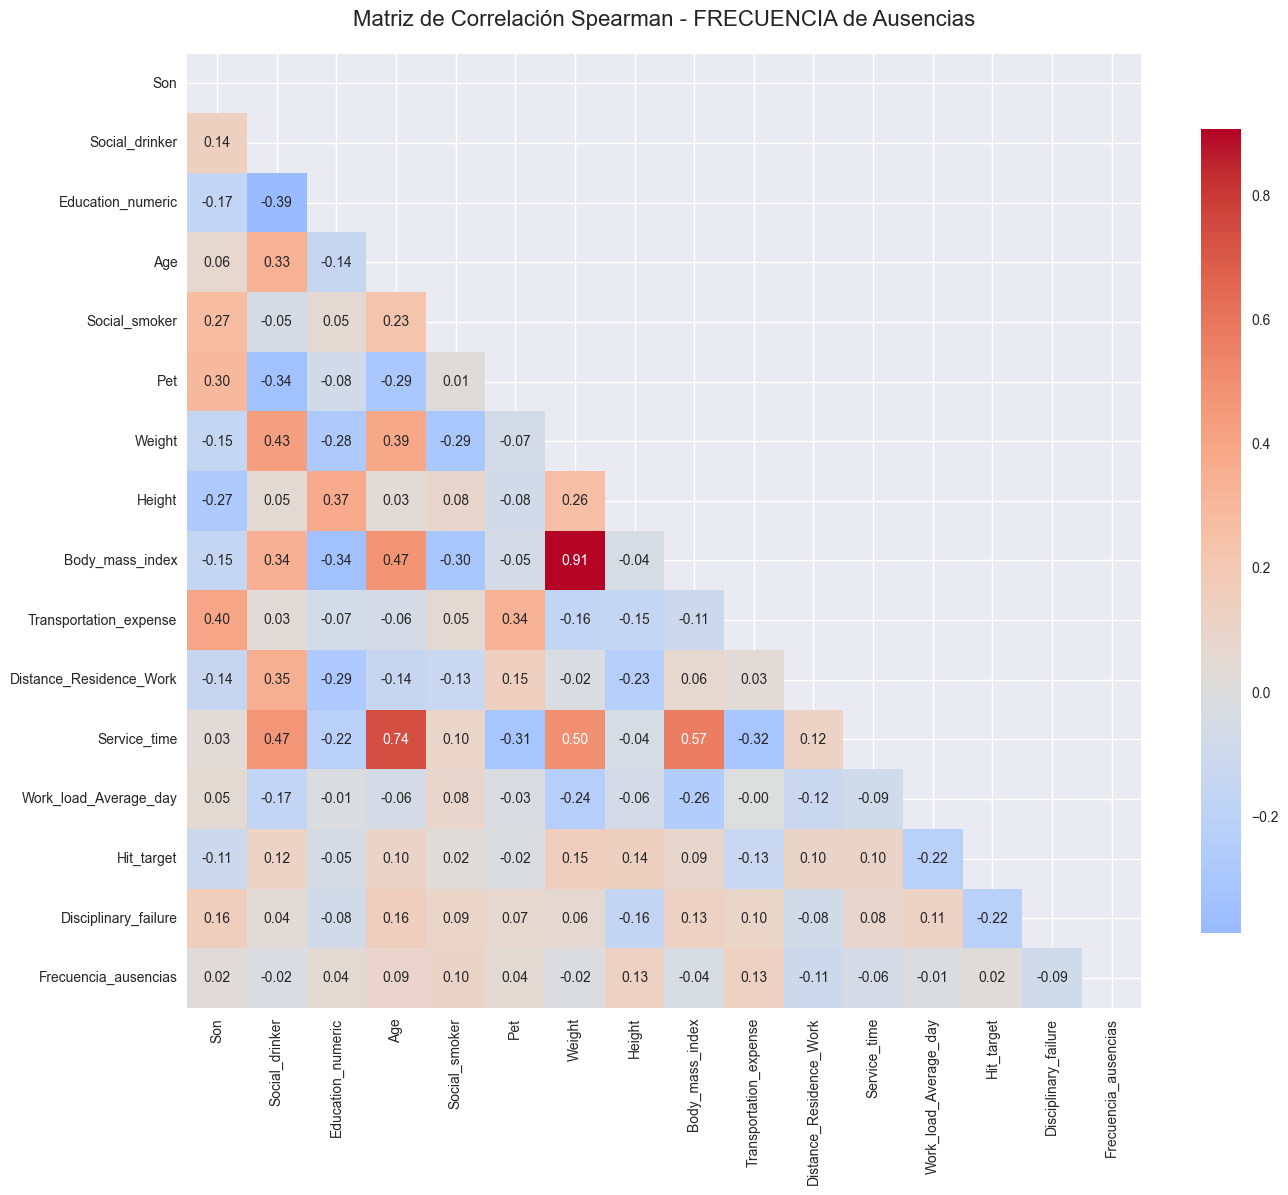

In [75]:
# Matriz de correlación para FRECUENCIA
todas_variables = variables_personales + variables_laborales + [target_variable]

corr_spearman_freq = frecuencia_ausencias[todas_variables].corr(method='spearman')

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_spearman_freq, dtype=bool))
sns.heatmap(corr_spearman_freq, mask=mask, annot=True, cmap='coolwarm', center=0,
           square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación Spearman - FRECUENCIA de Ausencias', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

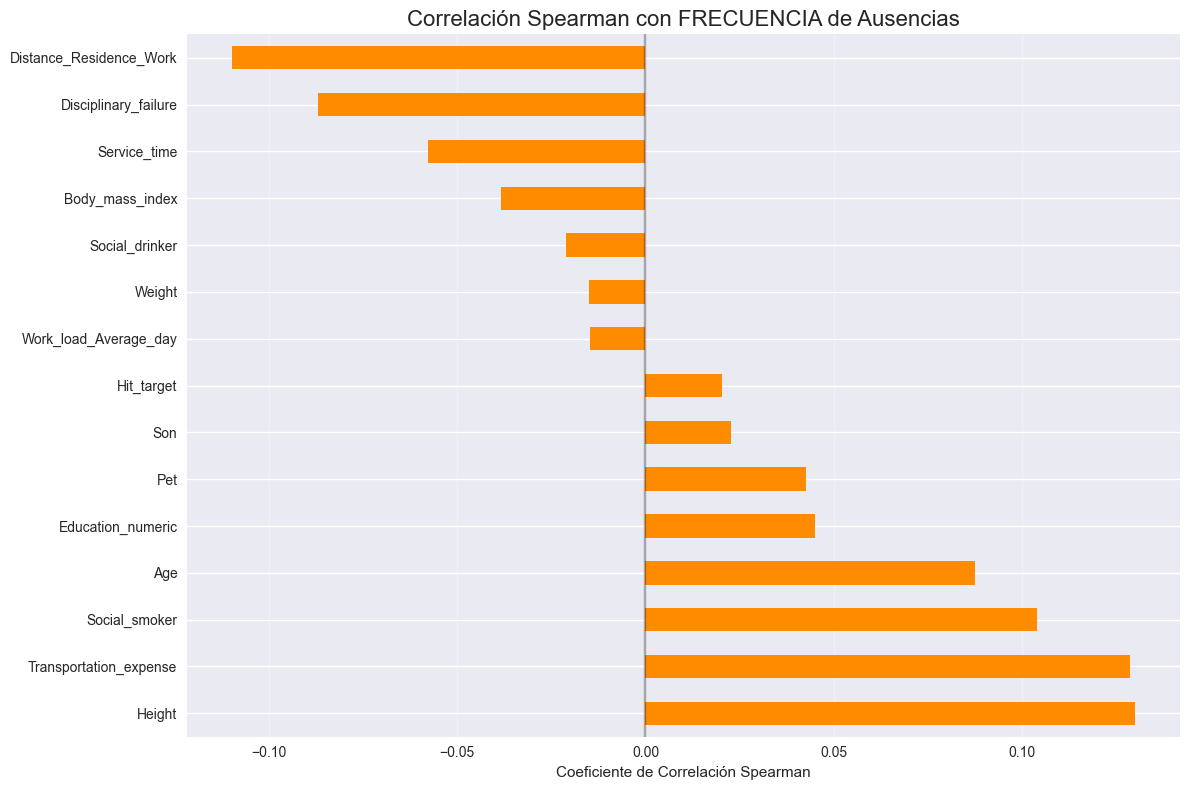

Top variables correlacionadas con FRECUENCIA:
Height                    0.129937
Transportation_expense    0.128688
Social_smoker             0.103826
Age                       0.087510
Education_numeric         0.044968
Pet                       0.042630
Son                       0.022699
Hit_target                0.020270
Work_load_Average_day    -0.014802
Weight                   -0.015059
dtype: float64


In [76]:
# Correlaciones con la FRECUENCIA
correlaciones_frecuencia = frecuencia_ausencias[todas_variables].corrwith(
    frecuencia_ausencias['Frecuencia_ausencias'], method='spearman')
correlaciones_frecuencia = correlaciones_frecuencia.drop('Frecuencia_ausencias').sort_values(ascending=False)

plt.figure(figsize=(12, 8))
correlaciones_frecuencia.plot(kind='barh', color='darkorange')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.title('Correlación Spearman con FRECUENCIA de Ausencias', fontsize=16)
plt.xlabel('Coeficiente de Correlación Spearman')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top variables correlacionadas con FRECUENCIA:")
print(correlaciones_frecuencia.head(10))

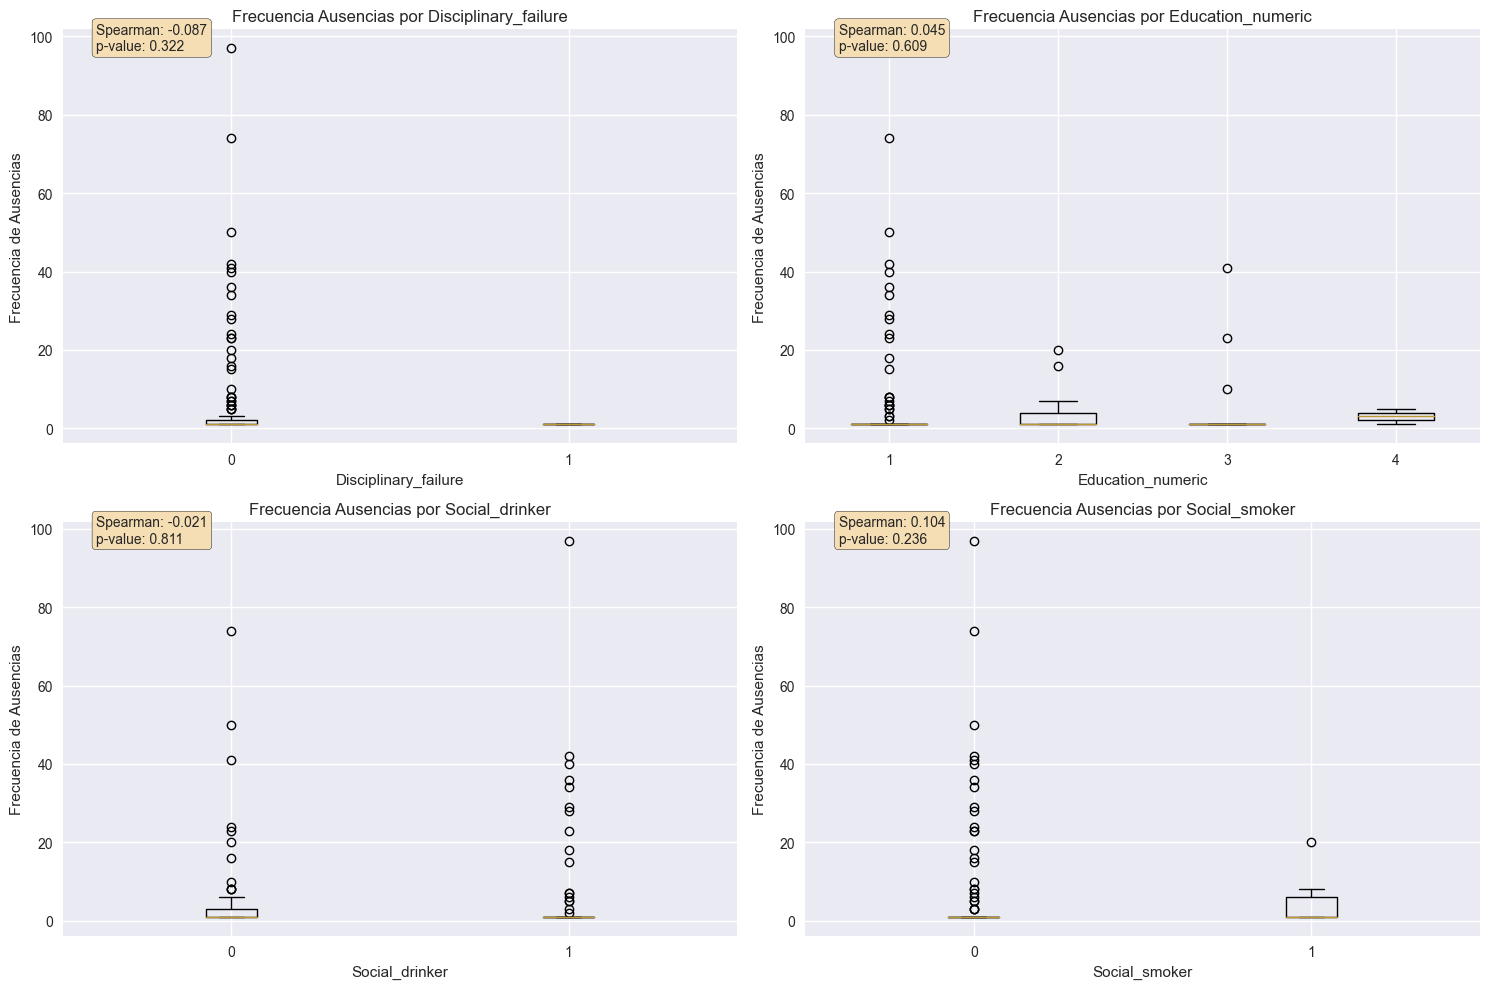

In [77]:
# Variables categóricas para frecuencia
categorical_vars = ['Disciplinary_failure', 'Education_numeric', 'Social_drinker', 'Social_smoker']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(categorical_vars):
    data_to_plot = []
    categories = sorted(frecuencia_ausencias[var].unique())
    
    for category in categories:
        data_to_plot.append(frecuencia_ausencias[frecuencia_ausencias[var] == category]['Frecuencia_ausencias'])
    
    axes[i].boxplot(data_to_plot, labels=categories)
    axes[i].set_title(f'Frecuencia Ausencias por {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frecuencia de Ausencias')
    
    # Correlación Spearman
    corr, p_value = spearmanr(frecuencia_ausencias[var], frecuencia_ausencias['Frecuencia_ausencias'])
    axes[i].text(0.05, 0.95, f'Spearman: {corr:.3f}\np-value: {p_value:.3f}', 
                transform=axes[i].transAxes, bbox=dict(boxstyle="round", facecolor='wheat'))

plt.tight_layout()
plt.show()

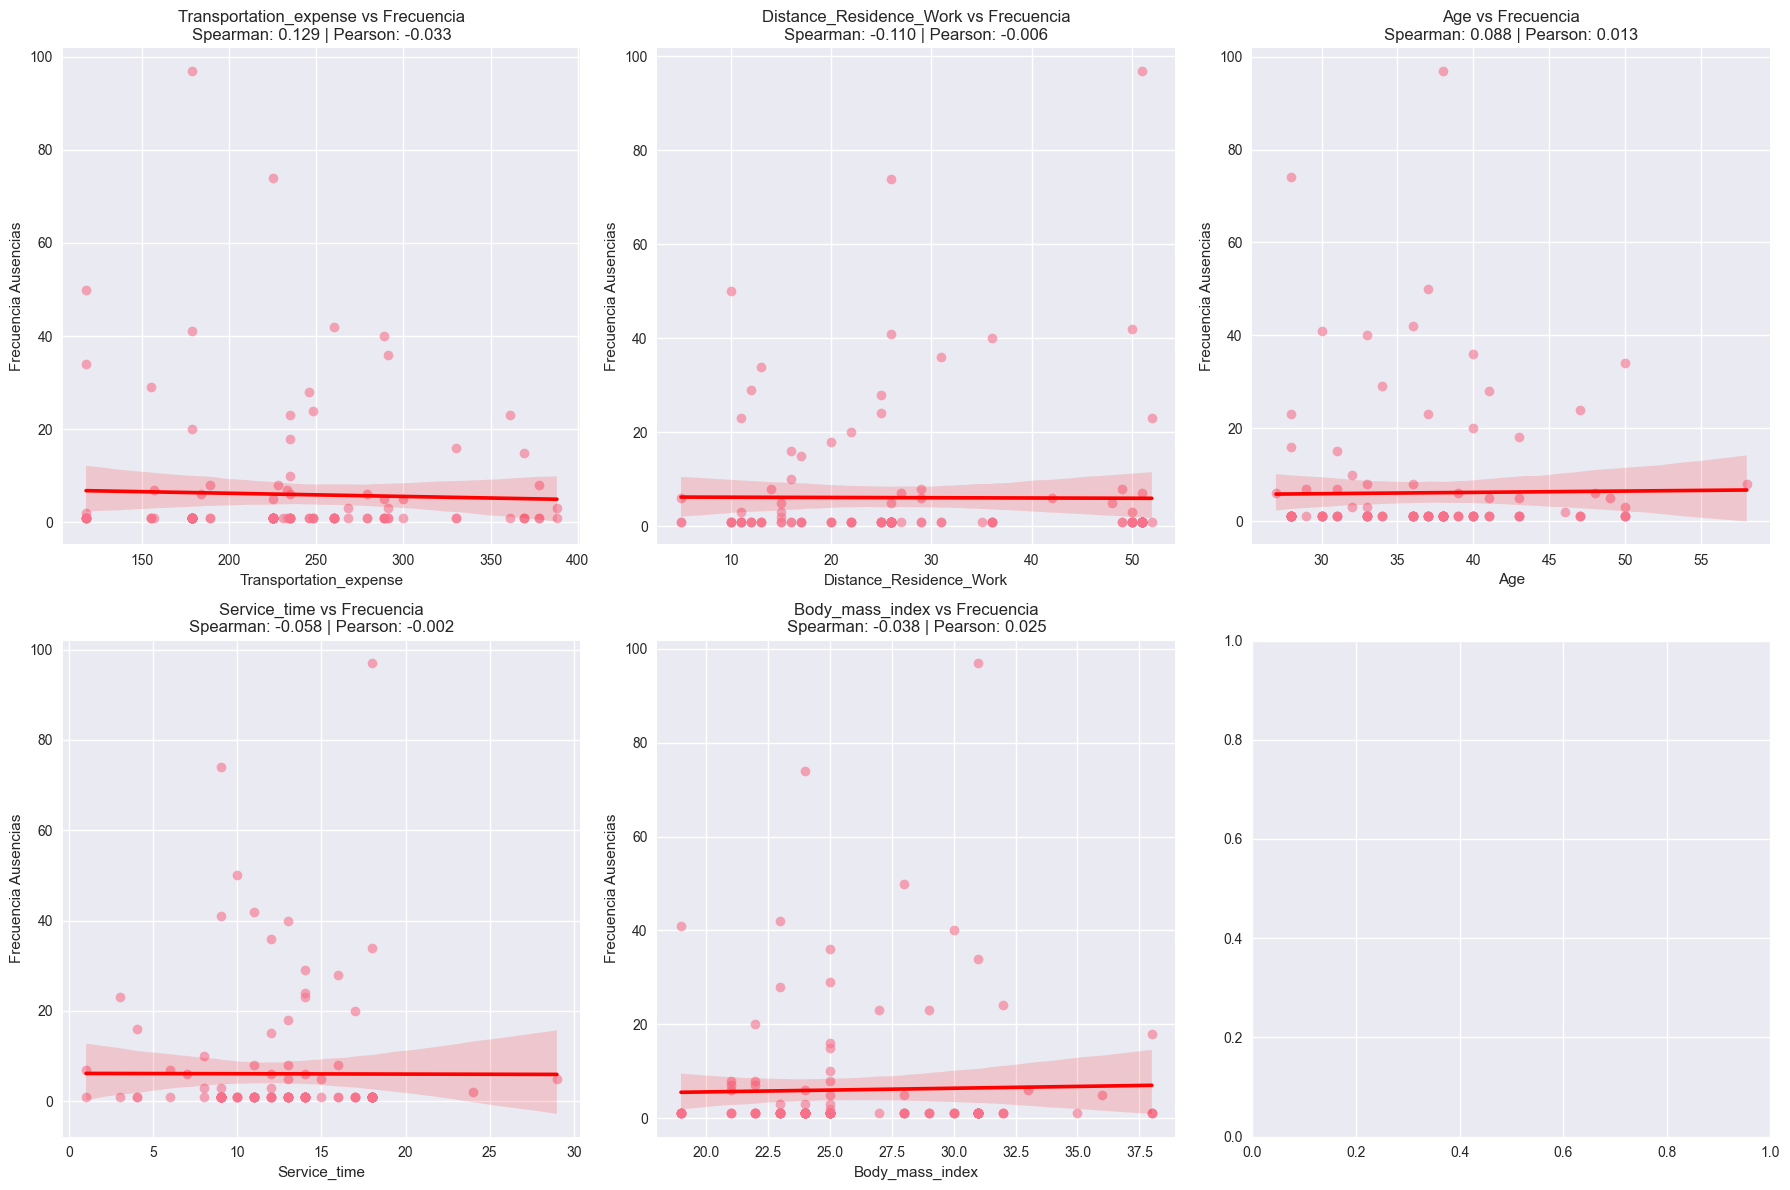

In [78]:
continuous_vars = ['Transportation_expense', 'Distance_Residence_Work', 'Age', 
                  'Service_time', 'Body_mass_index']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, var in enumerate(continuous_vars):
    if i < len(continuous_vars):
        sns.regplot(data=frecuencia_ausencias, x=var, y='Frecuencia_ausencias', 
                   ax=axes[i], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
        
        spear_corr, spear_p = spearmanr(frecuencia_ausencias[var], frecuencia_ausencias['Frecuencia_ausencias'])
        pearson_corr, pearson_p = pearsonr(frecuencia_ausencias[var], frecuencia_ausencias['Frecuencia_ausencias'])
        
        axes[i].set_title(f'{var} vs Frecuencia\nSpearman: {spear_corr:.3f} | Pearson: {pearson_corr:.3f}')
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Frecuencia Ausencias')

plt.tight_layout()
plt.show()

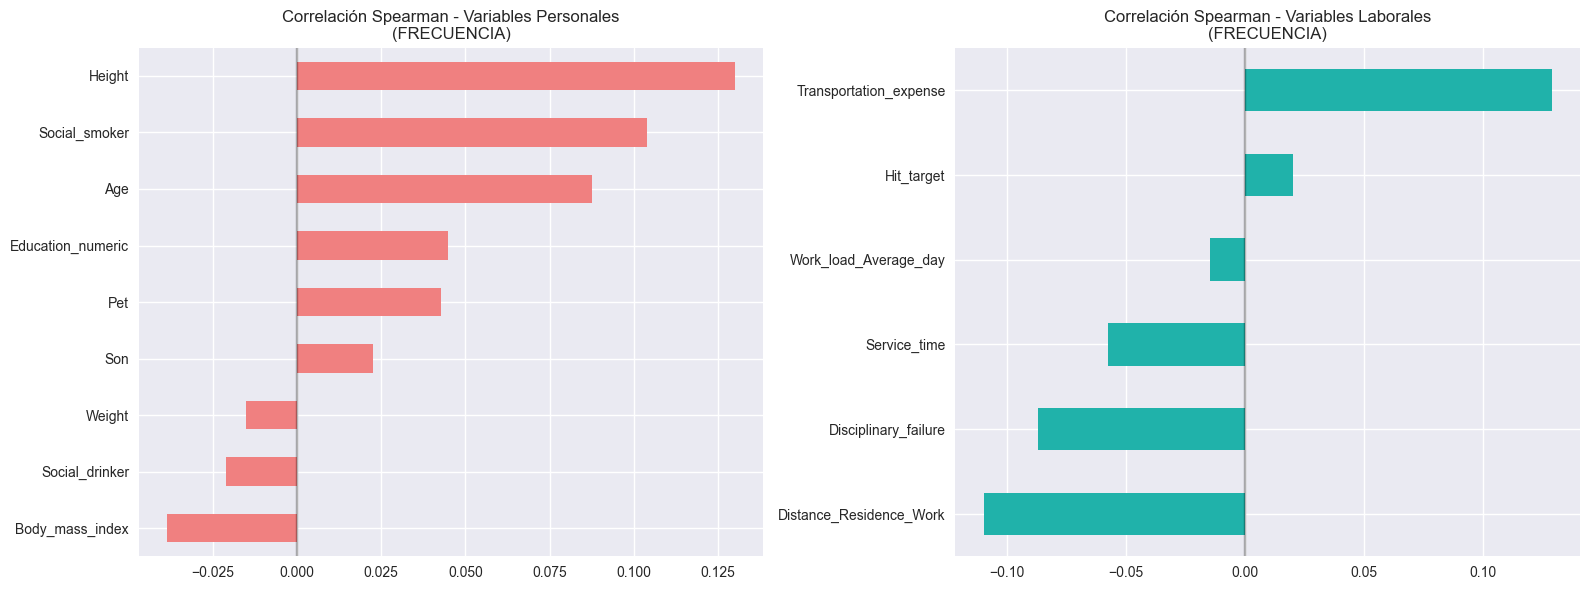

RESUMEN FRECUENCIA vs HORAS (para comparar):
Variables personales - Frecuencia: 0.056
Variables laborales - Frecuencia: 0.070


In [79]:
# Comparar correlaciones entre grupos para FRECUENCIA
corr_personal_freq = frecuencia_ausencias[variables_personales + ['Frecuencia_ausencias']].corrwith(
    frecuencia_ausencias['Frecuencia_ausencias'], method='spearman').drop('Frecuencia_ausencias')

corr_laboral_freq = frecuencia_ausencias[variables_laborales + ['Frecuencia_ausencias']].corrwith(
    frecuencia_ausencias['Frecuencia_ausencias'], method='spearman').drop('Frecuencia_ausencias')

# Gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

corr_personal_freq.sort_values().plot(kind='barh', ax=ax1, color='lightcoral')
ax1.set_title('Correlación Spearman - Variables Personales\n(FRECUENCIA)')
ax1.axvline(x=0, color='black', linestyle='-', alpha=0.3)

corr_laboral_freq.sort_values().plot(kind='barh', ax=ax2, color='lightseagreen')
ax2.set_title('Correlación Spearman - Variables Laborales\n(FRECUENCIA)')
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

print("RESUMEN FRECUENCIA vs HORAS (para comparar):")
print("="*50)
print("Variables personales - Frecuencia:", f"{corr_personal_freq.abs().mean():.3f}")
print("Variables laborales - Frecuencia:", f"{corr_laboral_freq.abs().mean():.3f}")

#### por empleado

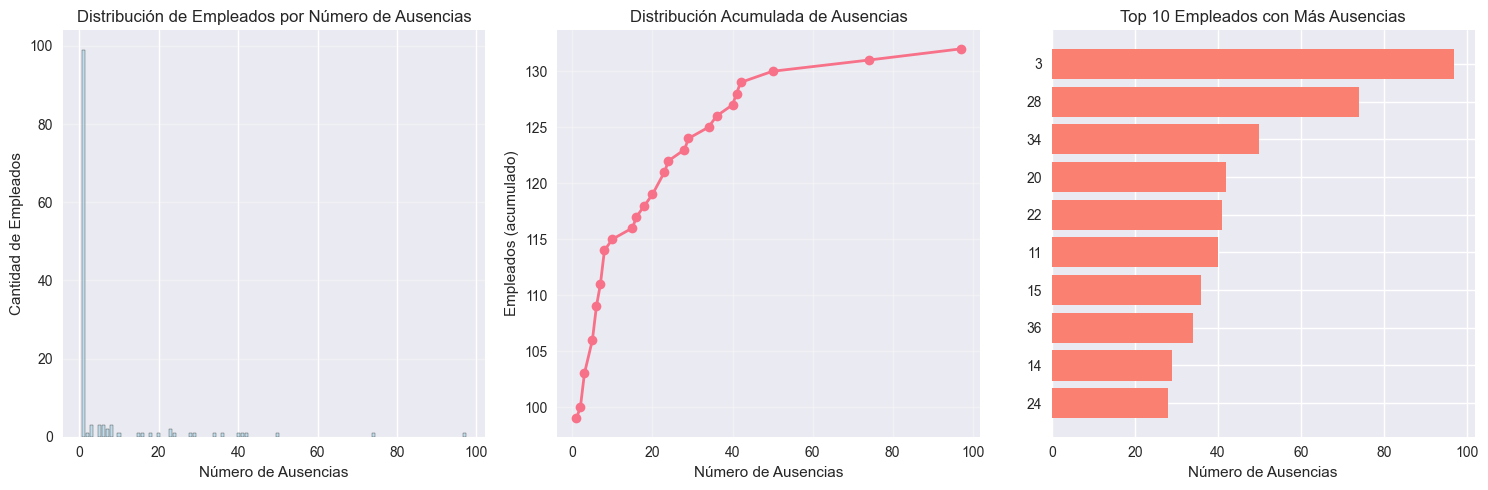

Resumen de frecuencia por empleado:
Total de empleados: 132
Total de ausencias registradas: 801
Promedio de ausencias por empleado: 6.07
Mediana de ausencias por empleado: 1.00


In [80]:
# Análisis detallado de la distribución de frecuencia
frecuencia_counts = frecuencia_ausencias['Frecuencia_ausencias'].value_counts().sort_index()

plt.figure(figsize=(15, 5))

# Gráfico 1: Distribución de frecuencia
plt.subplot(1, 3, 1)
plt.bar(frecuencia_counts.index, frecuencia_counts.values, color='lightblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de Empleados por Número de Ausencias')
plt.xlabel('Número de Ausencias')
plt.ylabel('Cantidad de Empleados')
plt.grid(axis='y', alpha=0.3)

# Gráfico 2: Distribución acumulada
plt.subplot(1, 3, 2)
frecuencia_acumulada = frecuencia_ausencias['Frecuencia_ausencias'].value_counts().sort_index().cumsum()
plt.plot(frecuencia_acumulada.index, frecuencia_acumulada.values, marker='o', linewidth=2)
plt.title('Distribución Acumulada de Ausencias')
plt.xlabel('Número de Ausencias')
plt.ylabel('Empleados (acumulado)')
plt.grid(True, alpha=0.3)

# Gráfico 3: Top empleados con más ausencias
plt.subplot(1, 3, 3)
top_ausentes = frecuencia_ausencias.nlargest(10, 'Frecuencia_ausencias')
plt.barh(range(len(top_ausentes)), top_ausentes['Frecuencia_ausencias'], color='salmon')
plt.yticks(range(len(top_ausentes)), top_ausentes['ID'])
plt.title('Top 10 Empleados con Más Ausencias')
plt.xlabel('Número de Ausencias')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print("Resumen de frecuencia por empleado:")
print(f"Total de empleados: {len(frecuencia_ausencias)}")
print(f"Total de ausencias registradas: {frecuencia_ausencias['Frecuencia_ausencias'].sum()}")
print(f"Promedio de ausencias por empleado: {frecuencia_ausencias['Frecuencia_ausencias'].mean():.2f}")
print(f"Mediana de ausencias por empleado: {frecuencia_ausencias['Frecuencia_ausencias'].median():.2f}")

In [81]:
# Tabla resumen detallada para FRECUENCIA
resumen_frecuencia = []

for variable in variables_personales + variables_laborales:
    spear_corr, spear_p = spearmanr(frecuencia_ausencias[variable], frecuencia_ausencias['Frecuencia_ausencias'])
    pearson_corr, pearson_p = pearsonr(frecuencia_ausencias[variable], frecuencia_ausencias['Frecuencia_ausencias'])
    
    # Clasificar la fuerza de la correlación
    fuerza_spearman = "Débil" if abs(spear_corr) < 0.3 else "Moderada" if abs(spear_corr) < 0.7 else "Fuerte"
    fuerza_pearson = "Débil" if abs(pearson_corr) < 0.3 else "Moderada" if abs(pearson_corr) < 0.7 else "Fuerte"
    
    resumen_frecuencia.append({
        'Variable': variable,
        'Tipo': 'Personal' if variable in variables_personales else 'Laboral',
        'Spearman_Corr': spear_corr,
        'Spearman_p_value': spear_p,
        'Pearson_Corr': pearson_corr,
        'Pearson_p_value': pearson_p,
        'Significativo': spear_p < 0.05,
        'Fuerza_Spearman': fuerza_spearman
    })

df_resumen_frecuencia = pd.DataFrame(resumen_frecuencia)
df_resumen_frecuencia = df_resumen_frecuencia.sort_values('Spearman_Corr', key=abs, ascending=False)

# Mostrar solo variables significativas
significativas_frecuencia = df_resumen_frecuencia[df_resumen_frecuencia['Significativo']]
print("VARIABLES SIGNIFICATIVAMENTE CORRELACIONADAS CON FRECUENCIA:")
print("="*70)
print(significativas_frecuencia[['Variable', 'Tipo', 'Spearman_Corr', 'Spearman_p_value', 'Fuerza_Spearman']].to_string(index=False))

VARIABLES SIGNIFICATIVAMENTE CORRELACIONADAS CON FRECUENCIA:
Empty DataFrame
Columns: [Variable, Tipo, Spearman_Corr, Spearman_p_value, Fuerza_Spearman]
Index: []


In [82]:
# Crear categorías de frecuencia
bins = [0, 1, 3, 5, 10, 100]
labels = ['Muy Baja (0-1)', 'Baja (2-3)', 'Media (4-5)', 'Alta (6-10)', 'Muy Alta (>10)']
frecuencia_ausencias['Categoria_Frecuencia'] = pd.cut(frecuencia_ausencias['Frecuencia_ausencias'], 
                                                     bins=bins, labels=labels, right=True)

# Análisis por categorías
categoria_stats = frecuencia_ausencias.groupby('Categoria_Frecuencia').agg({
    'Frecuencia_ausencias': 'count',
    'Age': 'mean',
    'Service_time': 'mean',
    'Transportation_expense': 'mean',
    'Disciplinary_failure': 'mean'
}).rename(columns={'Frecuencia_ausencias': 'Cantidad_Empleados'})

print("\nESTADÍSTICAS POR CATEGORÍA DE FRECUENCIA:")
print("="*60)
print(categoria_stats)


ESTADÍSTICAS POR CATEGORÍA DE FRECUENCIA:
                      Cantidad_Empleados        Age  Service_time  \
Categoria_Frecuencia                                                
Muy Baja (0-1)                        99  35.616162     12.626263   
Baja (2-3)                             4  40.250000     13.250000   
Media (4-5)                            3  44.333333     19.000000   
Alta (6-10)                            9  37.000000      9.777778   
Muy Alta (>10)                        17  36.529412     12.176471   

                      Transportation_expense  Disciplinary_failure  
Categoria_Frecuencia                                                
Muy Baja (0-1)                    223.101010              0.030303  
Baja (2-3)                        266.250000              0.000000  
Media (4-5)                       271.333333              0.000000  
Alta (6-10)                       235.333333              0.000000  
Muy Alta (>10)                    236.294118              0

In [84]:
# Dividir en grupos: alta frecuencia vs baja frecuencia
mediana = frecuencia_ausencias['Frecuencia_ausencias'].median()
alta_frecuencia = frecuencia_ausencias[frecuencia_ausencias['Frecuencia_ausencias'] > mediana]
baja_frecuencia = frecuencia_ausencias[frecuencia_ausencias['Frecuencia_ausencias'] <= mediana]

print(f"\nCOMPARACIÓN ENTRE GRUPOS (Mediana = {mediana} ausencias):")
print("="*50)
print(f"Empleados con baja frecuencia: {len(baja_frecuencia)}")
print(f"Empleados con alta frecuencia: {len(alta_frecuencia)}")

# Comparar medias de variables significativas
variables_comparar = significativas_frecuencia['Variable'].head(5).tolist()

comparacion_grupos = pd.DataFrame({
    'Variable': variables_comparar,
    'Baja_Frecuencia_Media': [baja_frecuencia[var].mean() for var in variables_comparar],
    'Alta_Frecuencia_Media': [alta_frecuencia[var].mean() for var in variables_comparar],
    'Diferencia': [alta_frecuencia[var].mean() - baja_frecuencia[var].mean() for var in variables_comparar]
})

print("\nComparación de medias entre grupos:")
print(comparacion_grupos.to_string(index=False))


COMPARACIÓN ENTRE GRUPOS (Mediana = 1.0 ausencias):
Empleados con baja frecuencia: 99
Empleados con alta frecuencia: 33

Comparación de medias entre grupos:
Empty DataFrame
Columns: [Variable, Baja_Frecuencia_Media, Alta_Frecuencia_Media, Diferencia]
Index: []


In [85]:
print("\n" + "="*80)
print("RESUMEN EJECUTIVO - ANÁLISIS DE FRECUENCIA DE AUSENCIAS")
print("="*80)

print(f"\n📊 DATOS GENERALES:")
print(f"   • Total de empleados analizados: {len(frecuencia_ausencias)}")
print(f"   • Total de ausencias registradas: {frecuencia_ausencias['Frecuencia_ausencias'].sum()}")
print(f"   • Rango de ausencias por empleado: {frecuencia_ausencias['Frecuencia_ausencias'].min()} - {frecuencia_ausencias['Frecuencia_ausencias'].max()}")
print(f"   • Mediana de ausencias por empleado: {mediana}")

print(f"\n🔍 VARIABLES MÁS IMPORTANTES:")
for idx, row in significativas_frecuencia.head(5).iterrows():
    direccion = "positiva" if row['Spearman_Corr'] > 0 else "negativa"
    print(f"   • {row['Variable']} ({row['Tipo']}): {row['Spearman_Corr']:.3f} ({direccion}) - {row['Fuerza_Spearman']}")

print(f"\n💡 RECOMENDACIONES:")
if len(significativas_frecuencia) > 0:
    top_var = significativas_frecuencia.iloc[0]
    print(f"   • Enfocar intervenciones en: {top_var['Variable']}")
    print(f"   • Variables significativas encontradas: {len(significativas_frecuencia)}")
else:
    print("   • No se encontraron correlaciones significativas fuertes")

print("="*80)


RESUMEN EJECUTIVO - ANÁLISIS DE FRECUENCIA DE AUSENCIAS

📊 DATOS GENERALES:
   • Total de empleados analizados: 132
   • Total de ausencias registradas: 801
   • Rango de ausencias por empleado: 1 - 97
   • Mediana de ausencias por empleado: 1.0

🔍 VARIABLES MÁS IMPORTANTES:

💡 RECOMENDACIONES:
   • No se encontraron correlaciones significativas fuertes
